# Level 2 - Task 1: Regression Analysis

### Objectives:
1. Split dataset into 80% training and 20% testing sets.
2. Train a Simple Linear Regression model using scikit-learn to predict Total day charge from Total day minutes.
3. Calculate evaluation metrics ($R^2$, MSE, RMSE, MAE).
4. Interpret regression parameters and plot the fitted line against test observations.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load data
df = pd.read_csv('churn-bigml-20 2.csv')

# 2. Define Feature matrix (X) and Target vector (y)
X = df[['Total day minutes']]
y = df['Total day charge']

# 3. 80/20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training observations: {X_train.shape[0]}')
print(f'Testing observations:  {X_test.shape[0]}')

FileNotFoundError: [Errno 2] No such file or directory: 'churn-bigml-20 2.csv'

In [2]:
df = pd.read_csv('../Desktop/churn-bigml-20 2.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../Desktop/churn-bigml-20 2.csv'

In [3]:
import os

# Expands automatically to C:/Users/<YourUsername>/Desktop
desktop_path = os.path.expanduser('~/Desktop/churn-bigml-20 2.csv')
df = pd.read_csv(desktop_path)

In [4]:
import glob
import os
import pandas as pd

# Find any csv files on Desktop
desktop_csvs = glob.glob(os.path.expanduser('~/Desktop/*.csv'))
print('CSV files found on Desktop:', desktop_csvs)

# Load the file automatically if found
if desktop_csvs:
  df = pd.read_csv(desktop_csvs[0])
  print('Successfully loaded dataset with shape:', df.shape)
else:
  print('No CSV file found directly on Desktop.')

CSV files found on Desktop: ['C:\\Users\\user/Desktop\\churn-bigml-20 2.csv']
Successfully loaded dataset with shape: (667, 20)


In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Define Feature (X) and Target (y)
X = df[['Total day minutes']]
y = df['Total day charge']

# 2. 80/20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 3. Fit Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

slope = lr_model.coef_[0]
intercept = lr_model.intercept_

print(f'Slope (Coefficient): {slope:.4f}')
print(f'Intercept:           {intercept:.4f}')
print(
    f'Equation: Total Day Charge = ({slope:.4f} * Total Day Minutes) +'
    f' ({intercept:.4f})'
)

Slope (Coefficient): 0.1700
Intercept:           0.0003
Equation: Total Day Charge = (0.1700 * Total Day Minutes) + (0.0003)


In [6]:
# 4. Predict on test set
y_pred = lr_model.predict(X_test)

# 5. Calculate metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
mae = mean_absolute_error(y_test, y_pred)

metrics_table = pd.DataFrame(
    {
        'Metric': [
            'R-squared (R²)',
            'Mean Squared Error (MSE)',
            'Root Mean Squared Error (RMSE)',
            'Mean Absolute Error (MAE)',
        ],
        'Score': [f'{r2:.4f}', f'{mse:.6f}', f'{rmse:.6f}', f'{mae:.6f}'],
    }
)

display(metrics_table)

,Metric,Score
0,R-squared (R²),1.0000
1,Mean Squared Error (MSE),0.000008
2,Root Mean Squared Error (RMSE),0.002841
3,Mean Absolute Error (MAE),0.002473


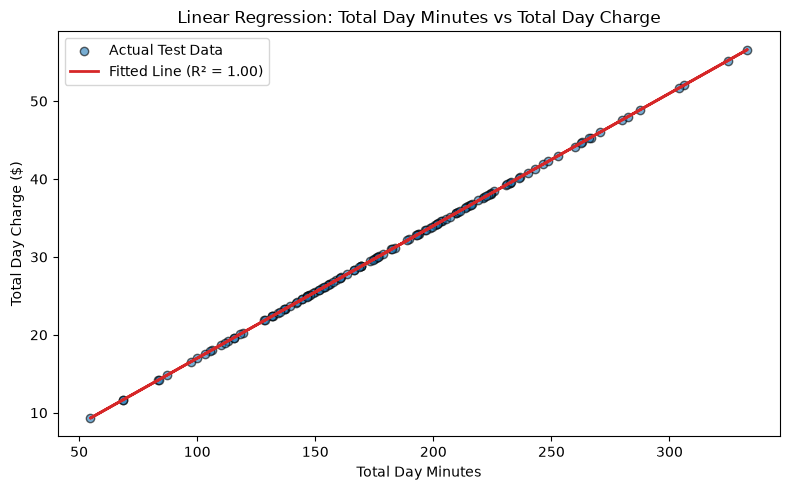

In [7]:
# 6. Plot test data vs regression line
plt.figure(figsize=(8, 5))
plt.scatter(
    X_test,
    y_test,
    color='#1f77b4',
    alpha=0.6,
    edgecolor='k',
    label='Actual Test Data',
)
plt.plot(
    X_test,
    y_pred,
    color='#d62728',
    linewidth=2,
    label=f'Fitted Line (R² = {r2:.2f})',
)

plt.title('Linear Regression: Total Day Minutes vs Total Day Charge', fontsize=12)
plt.xlabel('Total Day Minutes')
plt.ylabel('Total Day Charge ($)')
plt.legend()
plt.tight_layout()
plt.show()